In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

print("Libraries loaded")

Libraries loaded


In [2]:
# Cell 2: Load Processed Data
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv', index_col=0).squeeze()
X_val = pd.read_csv('../data/processed/X_val.csv', index_col=0)
y_val = pd.read_csv('../data/processed/y_val.csv', index_col=0).squeeze()
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
y_test = pd.read_csv('../data/processed/y_test.csv', index_col=0).squeeze()

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (95530, 8), Val: (20471, 8), Test: (20471, 8)


In [3]:
# Cell 3: Train Decision Tree
model = DecisionTreeRegressor(max_depth=10, random_state=42)
model.fit(X_train, y_train)

print("Model trained")
print(f"Max depth: {model.max_depth}")
print(f"Number of leaves: {model.get_n_leaves()}")

Model trained
Max depth: 10
Number of leaves: 643


In [4]:
# Cell 4: Make Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

print("Predictions made")

Predictions made


In [5]:
# Cell 5: Calculate Metrics
def calculate_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Set Metrics:")
    print(f"  RMSE: {rmse}")
    print(f"  MAE:  {mae}")
    print(f"  R²:   {r2}")
    
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2}

train_metrics = calculate_metrics(y_train, y_train_pred, "Train")
val_metrics = calculate_metrics(y_val, y_val_pred, "Validation")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test")


Train Set Metrics:
  RMSE: 157.85367766624483
  MAE:  55.91967880377138
  R²:   0.839065245693024

Validation Set Metrics:
  RMSE: 158.2259110621093
  MAE:  54.48673594826038
  R²:   0.7942007463896252

Test Set Metrics:
  RMSE: 137.91631368778326
  MAE:  46.935574398495525
  R²:   0.8392187930965211


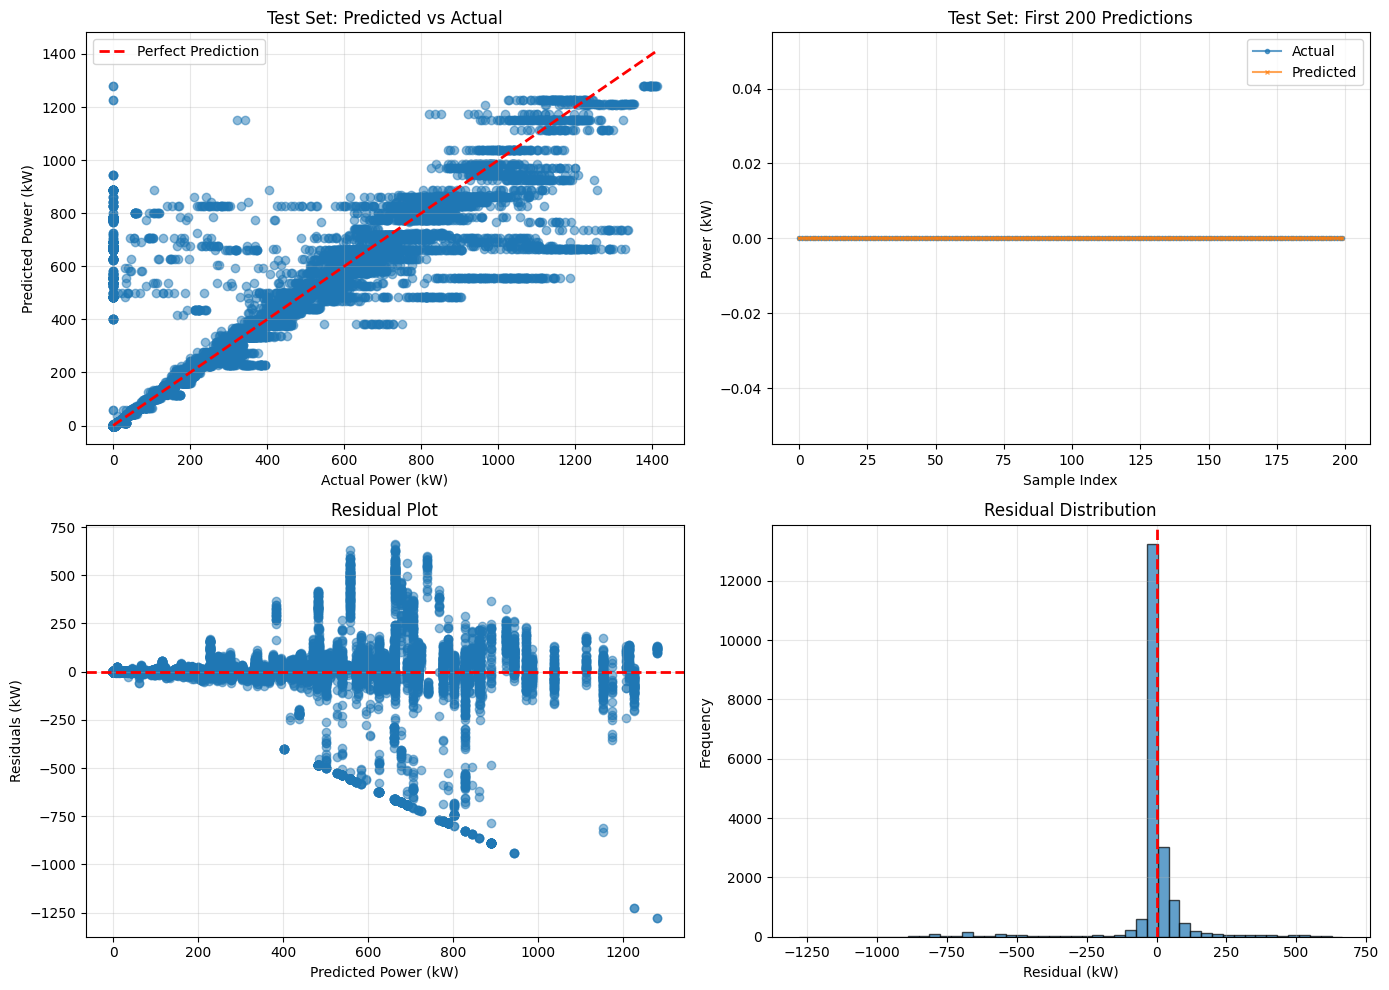

In [6]:
# Cell 6: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predicted vs Actual (Test Set)
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Power (kW)')
axes[0, 0].set_ylabel('Predicted Power (kW)')
axes[0, 0].set_title('Test Set: Predicted vs Actual')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Time Series Comparison (First 200 test samples)
axes[0, 1].plot(y_test.values[:200], label='Actual', marker='o', 
                markersize=3, alpha=0.7)
axes[0, 1].plot(y_test_pred[:200], label='Predicted', marker='x', 
                markersize=3, alpha=0.7)
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('Power (kW)')
axes[0, 1].set_title('Test Set: First 200 Predictions')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals
residuals = y_test - y_test_pred
axes[1, 0].scatter(y_test_pred, residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Power (kW)')
axes[1, 0].set_ylabel('Residuals (kW)')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residual Distribution
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residual (kW)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Cell 7: Save Model and Metrics
joblib.dump(model, '../models/decision_tree.pkl')
print("Model saved to ../models/decision_tree.pkl")

# Save metrics
metrics_df = pd.DataFrame({
    'Model': ['Decision Tree'],
    'Train_RMSE': [train_metrics['RMSE']],
    'Train_MAE': [train_metrics['MAE']],
    'Train_R²': [train_metrics['R²']],
    'Val_RMSE': [val_metrics['RMSE']],
    'Val_MAE': [val_metrics['MAE']],
    'Val_R²': [val_metrics['R²']],
    'Test_RMSE': [test_metrics['RMSE']],
    'Test_MAE': [test_metrics['MAE']],
    'Test_R²': [test_metrics['R²']]
})

metrics_df.to_csv('../models/decision_tree_metrics.csv', index=False)
print("Metrics saved to ../models/decision_tree_metrics.csv")

Model saved to ../models/decision_tree.pkl
Metrics saved to ../models/decision_tree_metrics.csv


In [8]:
# Cell 8: Summary
print("\nDECISION TREE COMPLETE")
print(f"Test R²: {test_metrics['R²']:.4f}")
print(f"Test RMSE: {test_metrics['RMSE']:.4f}")
print(f"Test MAE: {test_metrics['MAE']:.4f}")


DECISION TREE COMPLETE
Test R²: 0.8392
Test RMSE: 137.9163
Test MAE: 46.9356
